# Tarea Semanal 7
## Autor: Pedro Guzman


## Consigna 
Usando el archivo **ecg.mat** que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptadas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

**Ayuda:** Los detalles de cómo acceder a ecg.mat los pueden encontrar en `lectura_sigs.py`

Archivo *ECG.mat* (variables)

- **ecg_lead**: Registro de ECG muestreado a *fs* = 1 KHz durante una prueba de esfuerzo
- **qrs_pattern1**: Complejo de ondas QRS normal
- **heartbeat_pattern1**: Latido normal
- **heartbeat_pattern2**: Latido de origen ventricular
- **qrs_detections**: vector con las localizaciones (en # de muestras) donde ocurren los latidos

## Se pide:

**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** Utilice los resultados del ancho de banda estimado del ECG **en la Tarea Semanal** anterior. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.

**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe **al menos** dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** Para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-McClellan-Remez. Todos implementados en SciPy.Signal

**d)** Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.

**Ayuda:** Utilice el siguiente código como referencia para analizar los puntos 1 y 2). **También puede incluir otras regiones que considere de interés.**

---

**Bonus:**

- 💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.


## Solucion Propuesta

In [7]:
import pandas as pd
from scipy.io import loadmat, whosmat
import numpy as np
from scipy.signal import windows as win
import matplotlib.pyplot as plt
import scipy.signal as sp
from pytc2.sistemas_lineales import plot_plantilla ,group_delay, GroupDelay


# --- MAT ---
fs = 1000
mat_struct = loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)
t_ecg = np.arange(N) / fs
# Flatten the heartbeat patterns (same as you did for ecg_one_lead)
hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()

# Create their own time axes based on their actual length
t_hb1 = np.arange(len(hb_1)) / fs
t_hb2 = np.arange(len(hb_2)) / fs


**a)** **b)** Para la plantilla de diseño tome la desicion de que el ripple en banda de paso sea de 1dB y la atenuacion en bada de rechazo de 40dB, como voy a utilizar la funcion filtfilt para el filtrado de la señal (Esto proque filtro en computadora, si filtro con Hardware o una FPGA no puedo aplicar la funcion de filtrado en tiempo real con filtfilt), necesito dividir los parametros a la mitad, estos es debido a que la funcion filtfilt aplica la funcion de filtrado dos veces pero la segunda lo aplica de forma conjugada, de manera de tener un filtro de fase 0 (Fase constante). Muy util para el analisis en computadora.

Para los vlores de ancho de banda me base en la tarea semanal anterior, la frecuencia de pass depende principalmente del ancho de banda y ademas de que queremos eliminar la señal de continua. Las frecuencias de stop la elegi para no tener que pasar por la frecuencia de linea de 50Hz

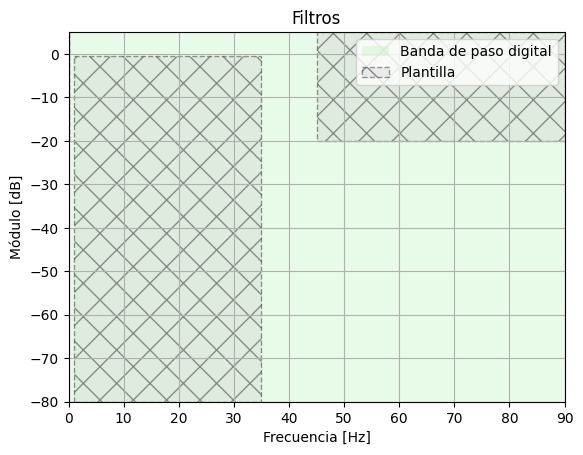

In [8]:
ripple = 0.5 # dB
atenuacion = 20 # dB

ws1 = .001 #Hz
wp1 = 1 #Hz
wp2 = 35.0 #Hz
ws2 = 45 #Hz

plt.figure()

plt.title('Filtros')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 90, -80, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

**c)** Procedo con el diseño de los filtros IIR, empiezo con un filtro Butter y despues con otro filtro Chebyshev.

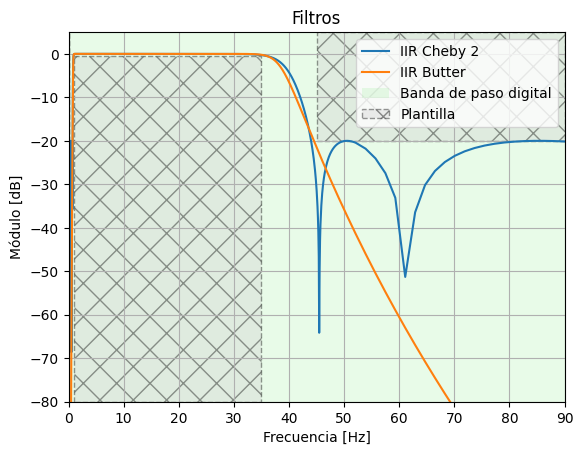

Orden del Filtro IIR Cheby 2: 12
Orden del Filtro IIR Butter : 30


In [11]:
sos_iir_cheby2 = sp.iirdesign(wp=[wp1-0.1,wp2+1], ws=[ws1,ws2], gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='cheby2', fs = fs)
sos_iir_butter = sp.iirdesign(wp=[wp1-0.1,wp2+1], ws=[ws1,ws2], gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='butter', fs = fs)

w_rad = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 250 ),
                       np.linspace(start = 2.1, stop = 34, num = 250 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 250 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 250 )] )

w_rad, h_iir_cheby2 = sp.freqz_sos(sos_iir_cheby2, worN=w_rad, fs = fs)
w_rad, h_iir_butter = sp.freqz_sos(sos_iir_butter, worN=w_rad, fs = fs)

plt.figure()

plt.plot(w_rad, 20*np.log10(np.abs(h_iir_cheby2)+1e-12), label = 'IIR Cheby 2' )
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_butter)+1e-12), label = 'IIR Butter' )

plt.title('Filtros')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 90, -80, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()
print(f"Orden del Filtro IIR Cheby 2: {sos_iir_cheby2.shape[0]*2}")
print(f"Orden del Filtro IIR Butter : {sos_iir_butter.shape[0]*2}")


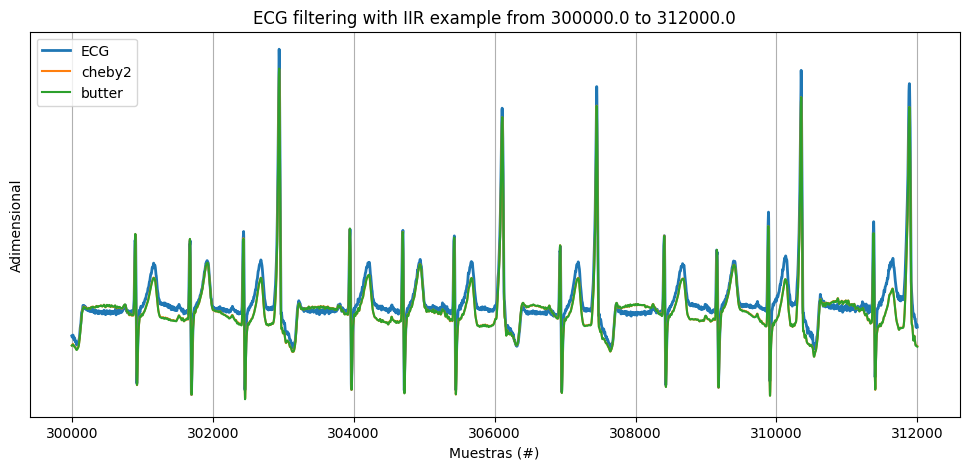

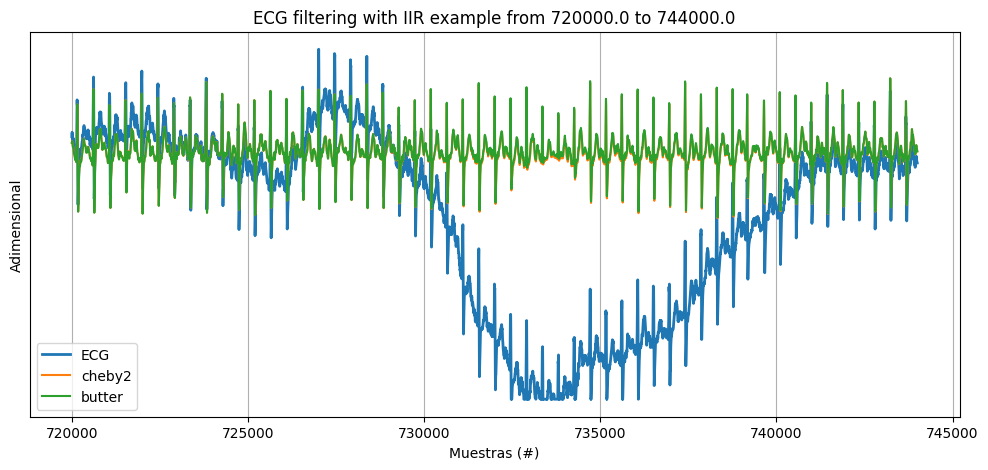

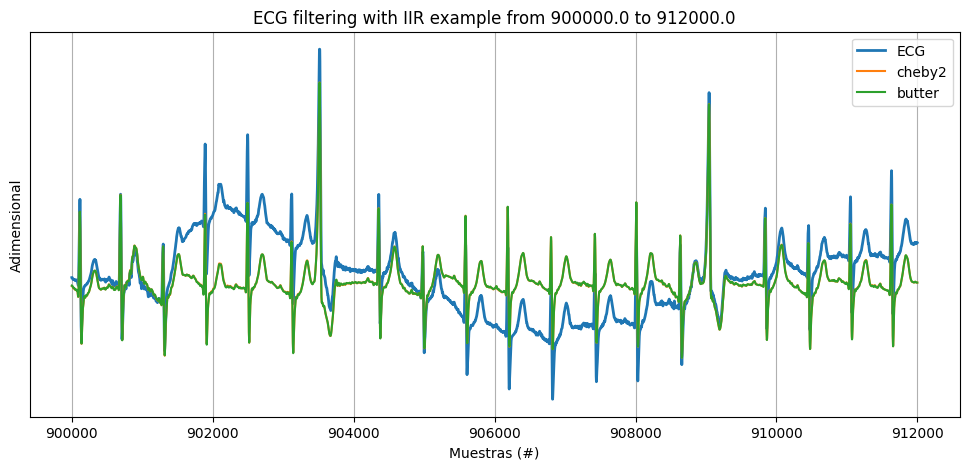

In [15]:

ECG_F_cheby2 = sp.sosfiltfilt(sos_iir_cheby2, ecg_one_lead)
ECG_F_butter = sp.sosfiltfilt(sos_iir_butter, ecg_one_lead)
###################################
#%% Regiones de interés sin ruido #
###################################

regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    plt.figure(figsize=(12,5))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_F_cheby2[zoom_region], label='cheby2')
    plt.plot(zoom_region, ECG_F_butter[zoom_region], label='butter')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering with IIR example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.grid()
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

In [ ]:
**c)** Procedo con el diseño de los filtros FIR, empiezo con la funcion FIRWIN

[FIR Hamming]          Orden: 4500  |  Coeficientes: 4501
[FIR Cuad. Mínimos]    Orden: 1100  |  Coeficientes: 1101


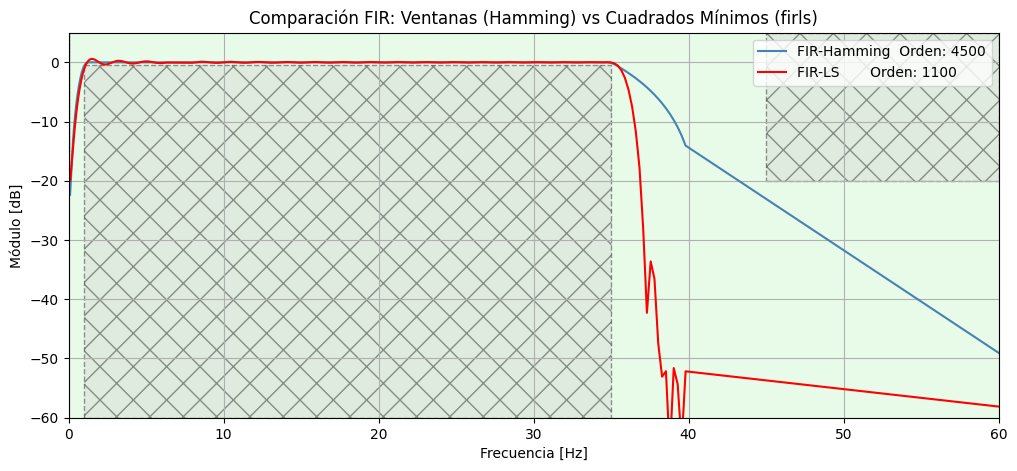

In [130]:
# =============================================
# COMPARACIÓN FIR: Ventanas (Hamming) vs Cuadrados Mínimos (firls)
# =============================================

fig_sz_x, fig_sz_y = 12, 5

# -----------------------------------------------
# FILTRO 1: FIR - Ventanas Hamming
# -----------------------------------------------
ws1_ham = 0.1   # Hz - Frecuencia de stop inferior
wp1_ham = 1    # Hz - Frecuencia de paso inferior
wp2_ham = 35.0   # Hz - Frecuencia de paso superior
ws2_ham = 41.0   # Hz - Frecuencia de stop superior

cant_coeficientes_ham = 4501  # Impar para FIR tipo I

num_ham = sp.firwin2(
    cant_coeficientes_ham,
    freq   = (0, ws1_ham, wp1_ham, wp2_ham, ws2_ham, fs/2),
    gain   = (0,       0,       1,       1,       0,    0),
    window = 'hamming',
    fs     = fs
)

orden_ham = num_ham.shape[0] - 1
print(f"[FIR Hamming]          Orden: {orden_ham}  |  Coeficientes: {num_ham.shape[0]}")

# -----------------------------------------------
# FILTRO 2: FIR - Cuadrados Mínimos (firls)
# -----------------------------------------------
ws1_ls = 0.1    # Hz - Frecuencia de stop inferior
wp1_ls = 0.9    # Hz - Frecuencia de paso inferior
wp2_ls = 35.0   # Hz - Frecuencia de paso superior
ws2_ls = 38.0   # Hz - Frecuencia de stop superior

cant_coeficientes_ls = 1101  # Impar para FIR tipo I

bands   = [0, ws1_ls, wp1_ls, wp2_ls, ws2_ls, fs/2]
gain    = [0,      0,      1,      1,      0,    0]

num_ls = sp.firls(cant_coeficientes_ls, bands, gain, fs=fs)

orden_ls = num_ls.shape[0] - 1
print(f"[FIR Cuad. Mínimos]    Orden: {orden_ls}  |  Coeficientes: {num_ls.shape[0]}")

# -----------------------------------------------
# Vector de frecuencias común para ambos filtros
# -----------------------------------------------
w = np.append(np.logspace(-1, 0.8, 250), np.logspace(0.9, 1.6, 250))
w = np.append(w, np.linspace(110, fs/2, 100, endpoint=True))

# -----------------------------------------------
# Respuesta en frecuencia de ambos filtros
# -----------------------------------------------
_, hh_ham = sp.freqz(num_ham, 1.0, w, fs=fs)
_, hh_ls  = sp.freqz(num_ls,  1.0, w, fs=fs)

# -----------------------------------------------
# Gráfico comparativo
# -----------------------------------------------
plt.figure(figsize=(fig_sz_x, fig_sz_y))

plt.plot(w, 20 * np.log10(abs(hh_ham) + 1e-12),
         label='FIR-Hamming  Orden: {:d}'.format(orden_ham),
         color='steelblue')

plt.plot(w, 20 * np.log10(abs(hh_ls) + 1e-12),
         label='FIR-LS       Orden: {:d}'.format(orden_ls),
         color='red')

plt.title('Comparación FIR: Ventanas (Hamming) vs Cuadrados Mínimos (firls)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 60, -60, 5])
axes_hdl = plt.gca()
axes_hdl.legend()

# Plantilla de diseño (referencia visual)
plot_plantilla(filter_type = 'bandpass',
               fpass       = (wp1, wp2),
               fstop       = (ws1, ws2),
               ripple      = ripple,
               attenuation = atenuacion,
               fs          = fs)

plt.show()

### Bonus Señal de Telefono


### Conclusion

